# Imports

In [1]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, spearmanr, kruskal, chi2_contingency

# Boxplot visualization

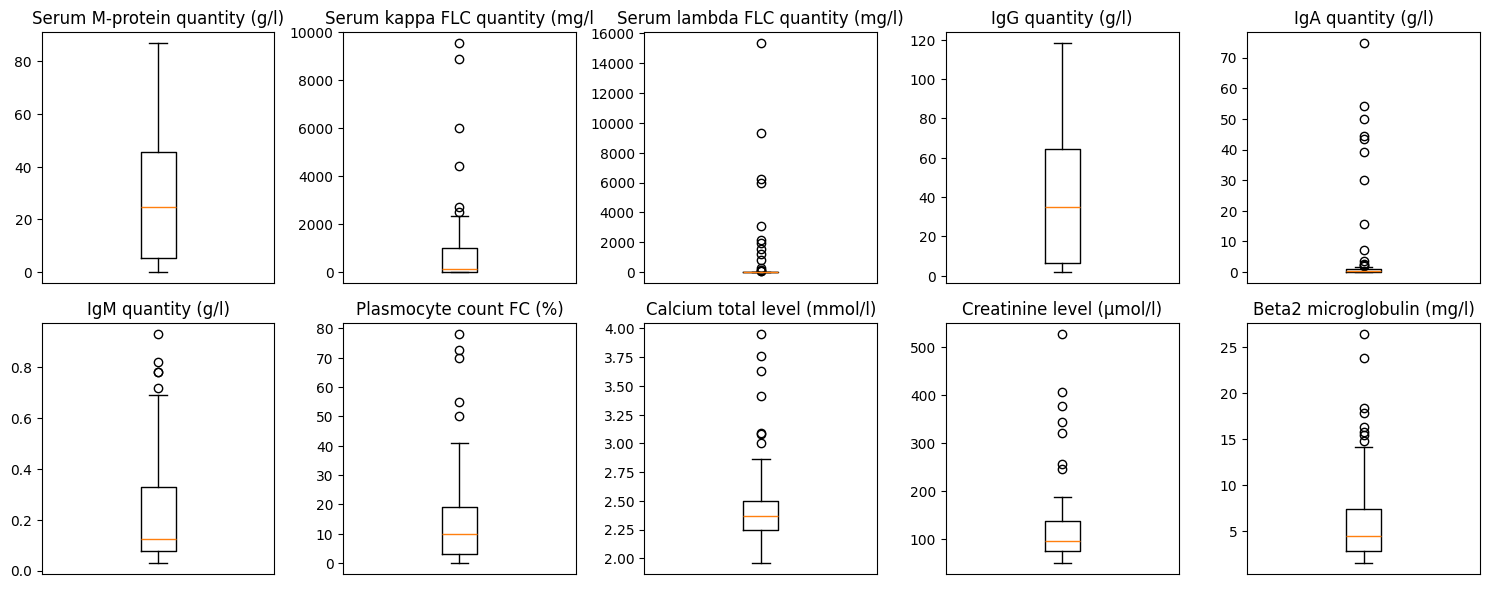

In [2]:
# 1. Load the clinical dataset with the appropriate encoding
df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# 2. Filter out only numerical columns for boxplot visualization
numeric_cols = df.select_dtypes(include=['number']).columns
total_columns = len(numeric_cols)

# 3. Configure grid layout for subplots (5 plots per row)
cols_per_row = 5
rows = math.ceil(total_columns / cols_per_row)

# 4. Set up the plotting style and initialize the dynamic grid figure
plt.style.use('default')
plt.figure(figsize=(cols_per_row * 3, rows * 3))

# 5. Loop through each numeric column and generate a boxplot
for index, col_name in enumerate(numeric_cols):
    # Create a subplot for the current feature
    plt.subplot(rows, cols_per_row, index + 1)

    # Draw boxplot dropping missing values to avoid rendering issues
    plt.boxplot(df[col_name].dropna())

    # Set plot styling
    plt.title(col_name, fontsize=12)
    plt.xticks([])  # Hide x-axis ticks for cleaner look

# 6. Adjust layout and display the final grid
plt.tight_layout()
plt.show()

# Violin-plot visualization

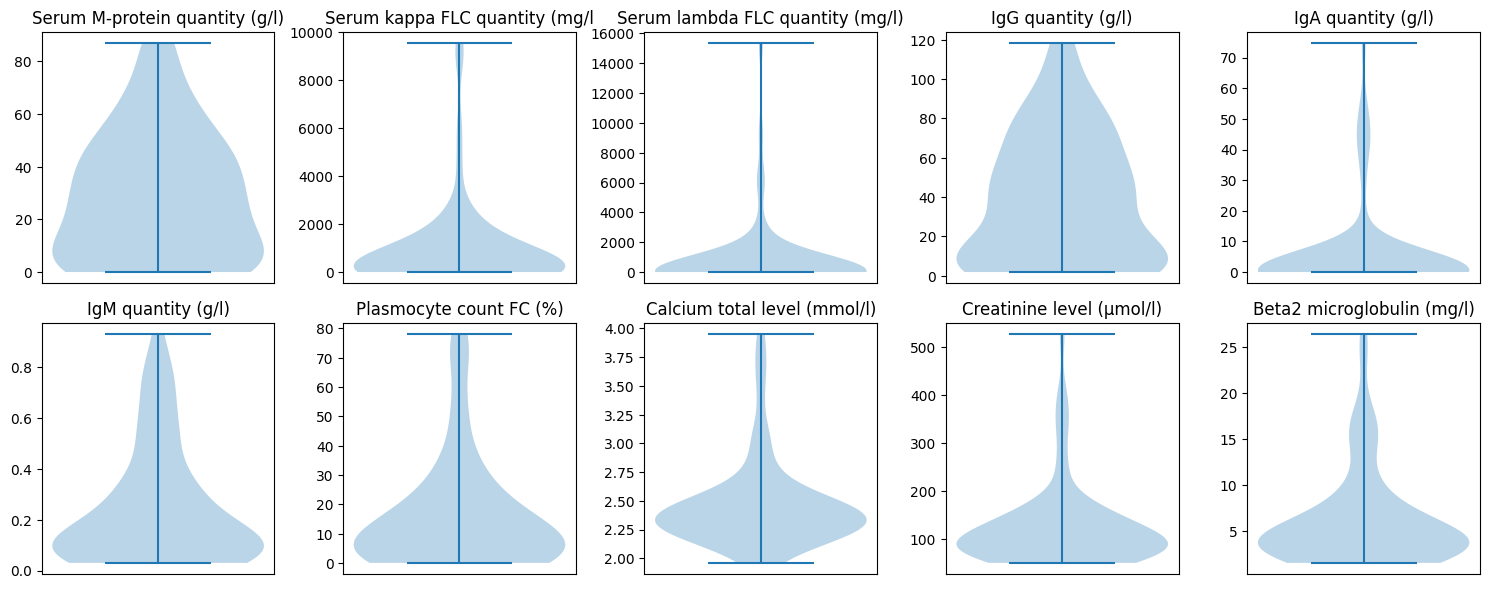

In [3]:
# 1. Load the clinical dataset with the appropriate encoding
df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# 2. Filter out only numerical columns for violin plot visualization
numeric_cols = df.select_dtypes(include=['number']).columns
total_columns = len(numeric_cols)

# 3. Configure grid layout for subplots (5 plots per row)
cols_per_row = 5
rows = math.ceil(total_columns / cols_per_row)

# 4. Set up the plotting style and initialize the dynamic grid figure
plt.style.use('default')
plt.figure(figsize=(cols_per_row * 3, rows * 3))

# 5. Loop through each numeric column and generate a violin plot
for index, col_name in enumerate(numeric_cols):
    # Create a subplot for the current feature
    plt.subplot(rows, cols_per_row, index + 1)

    # Draw violin plot dropping missing values to avoid rendering issues
    plt.violinplot(df[col_name].dropna())

    # Set plot styling
    plt.title(col_name, fontsize=12)
    plt.xticks([])  # Hide x-axis ticks for cleaner look

# 6. Adjust layout and display the final grid
plt.tight_layout()
plt.show()

# Histogram visualization

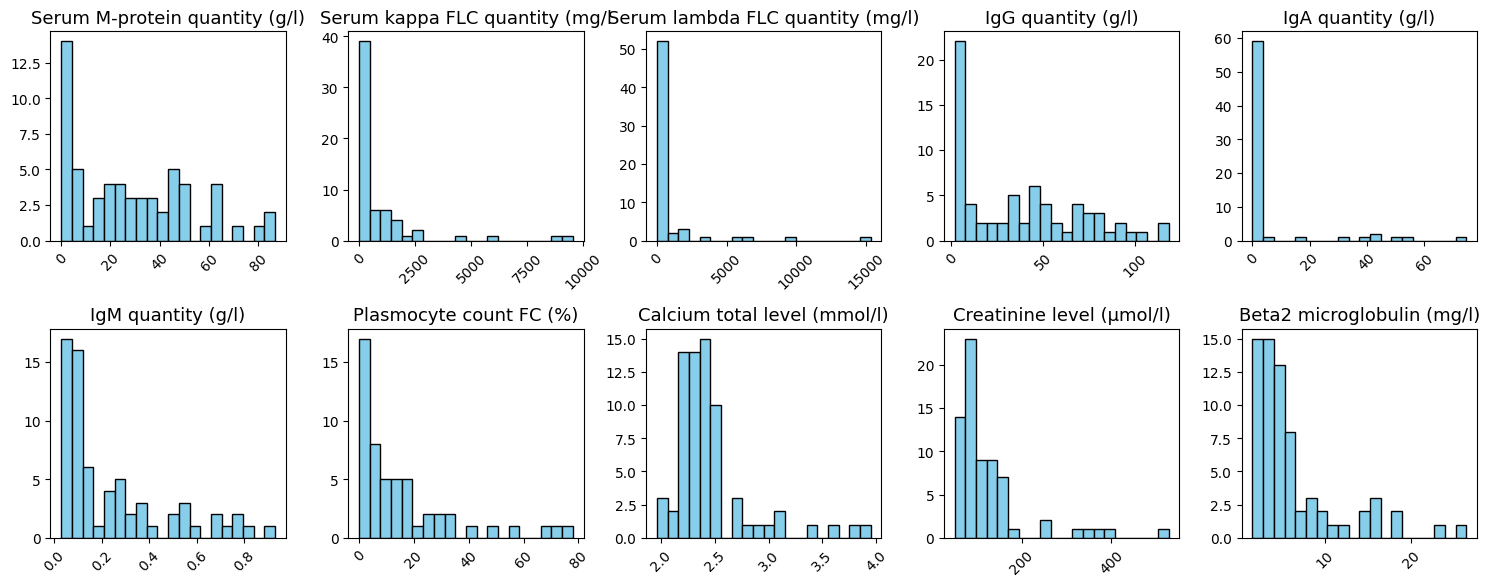

In [4]:
# 1. Load the clinical dataset with the appropriate encoding
df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# 2. Filter out only numerical columns for histogram visualization
numeric_cols = df.select_dtypes(include=['number']).columns
total_columns = len(numeric_cols)

# 3. Configure grid layout for subplots (5 plots per row)
cols_per_row = 5
rows = math.ceil(total_columns / cols_per_row)

# 4. Set up the plotting style and initialize the dynamic grid figure
plt.style.use('default')
plt.figure(figsize=(cols_per_row * 3, rows * 3))

# 5. Loop through each numeric column and generate a histogram
for index, col_name in enumerate(numeric_cols):
    # Create a subplot for the current feature
    plt.subplot(rows, cols_per_row, index + 1)

    # Draw histogram dropping missing values to avoid rendering issues
    plt.hist(df[col_name].dropna(), bins=20, color='skyblue', edgecolor='black')

    # Set plot styling and rotate labels to prevent overlapping
    plt.title(col_name, fontsize=13)
    plt.xticks(rotation=45)

# 6. Adjust layout and display the final grid
plt.tight_layout()
plt.show()

# Data normality test using Shapiro-Wilk

In [5]:
# 1. Load the clinical dataset with the appropriate encoding
df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# 2. Filter out only numerical columns for the normality test
numeric_cols = df.select_dtypes(include=['number']).columns

print("--- Shapiro-Wilk Normality Test Results ---")

# 3. Iterate through each numeric column and perform the test
for column in numeric_cols:
    # Drop missing values as the test requires complete data
    data = df[column].dropna()

    # Shapiro-Wilk test requires at least 3 data points
    if len(data) < 3:
        print(f"{column}: Skipped (not enough data points, minimum required is 3)")
        continue

    # Perform the test; '_' holds the W-statistic which we don't print
    _, p_value = shapiro(data)

    # Check the null hypothesis (p > 0.05 implies data is normally distributed)
    is_normal = p_value > 0.05
    print(f"{column}: p-value = {p_value:.5f} -> Is Normal: {is_normal}")

--- Shapiro-Wilk Normality Test Results ---
Serum M-protein quantity (g/l): p-value = 0.00080 -> Is Normal: False
Serum kappa FLC quantity (mg/l: p-value = 0.00000 -> Is Normal: False
Serum lambda FLC quantity (mg/l): p-value = 0.00000 -> Is Normal: False
IgG quantity (g/l): p-value = 0.00003 -> Is Normal: False
IgA quantity (g/l): p-value = 0.00000 -> Is Normal: False
IgM quantity (g/l): p-value = 0.00000 -> Is Normal: False
Plasmocyte count FC (%): p-value = 0.00000 -> Is Normal: False
Calcium total level (mmol/l): p-value = 0.00000 -> Is Normal: False
Creatinine level (µmol/l): p-value = 0.00000 -> Is Normal: False
Beta2 microglobulin (mg/l): p-value = 0.00000 -> Is Normal: False


# Spearman's correlation heatmap

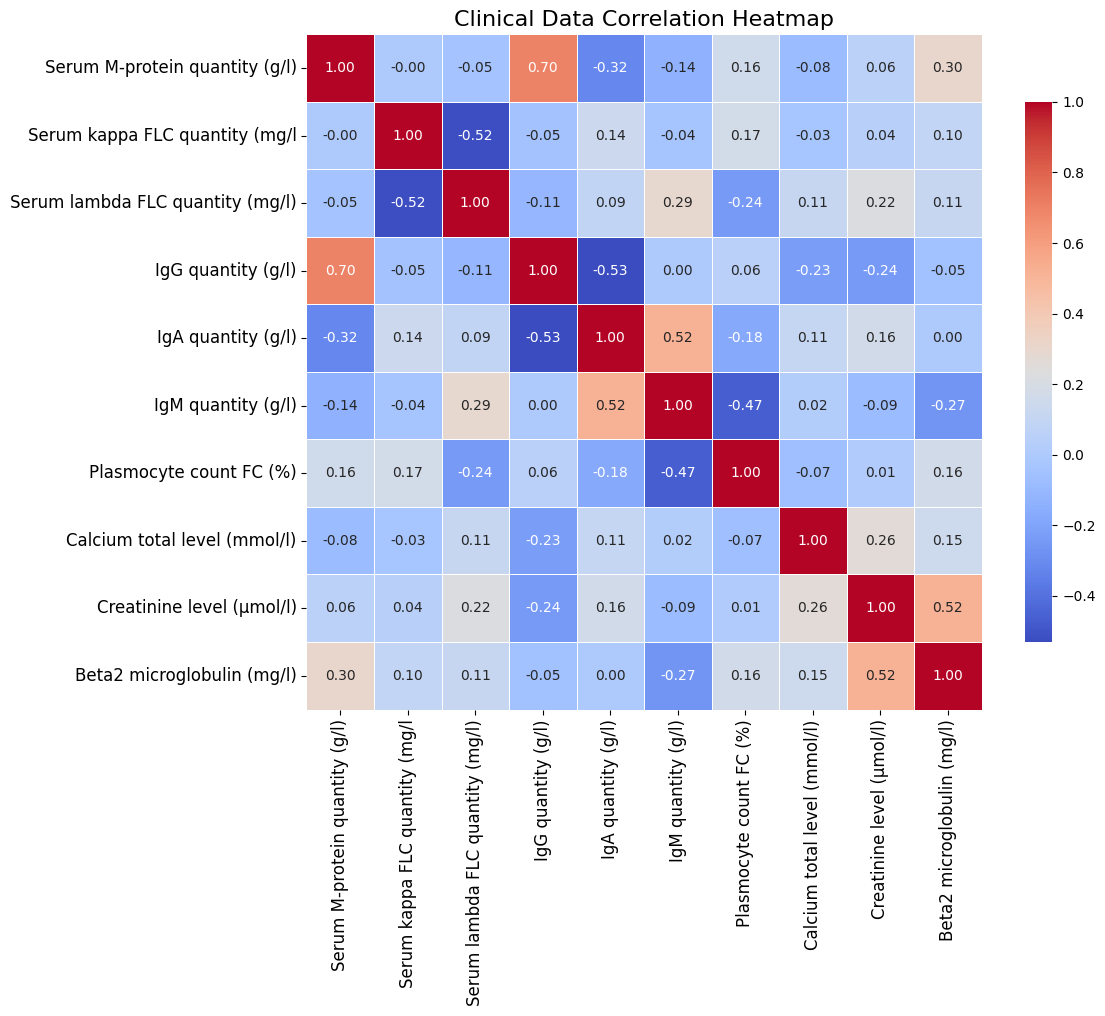

In [6]:
# 1. Load the clinical dataset with the appropriate encoding
df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# 2. Filter out only numerical columns for correlation analysis
numeric_cols = df.select_dtypes(include=['number']).columns

# 3. Calculate the Spearman rank correlation matrix
# Note: You can switch the method to "pearson" if linear correlation is needed
correlation_matrix = df[numeric_cols].corr(method="spearman")

# 4. Initialize the figure with a fixed size suitable for matrix visualization
plt.figure(figsize=(12, 10))

# 5. Generate the heatmap with customized annotations and styling
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

# 6. Set font sizes for labels and add a prominent title
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Clinical Data Correlation Heatmap", fontsize=16)

# 7. Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Scatter plot

--- Spearman Correlation Analysis ---
Features: 'Beta2 microglobulin (mg/l)' vs 'Creatinine level (µmol/l)'
Correlation Coefficient (rho): 0.5167
p-value: 0.00001
Statistically Significant: True



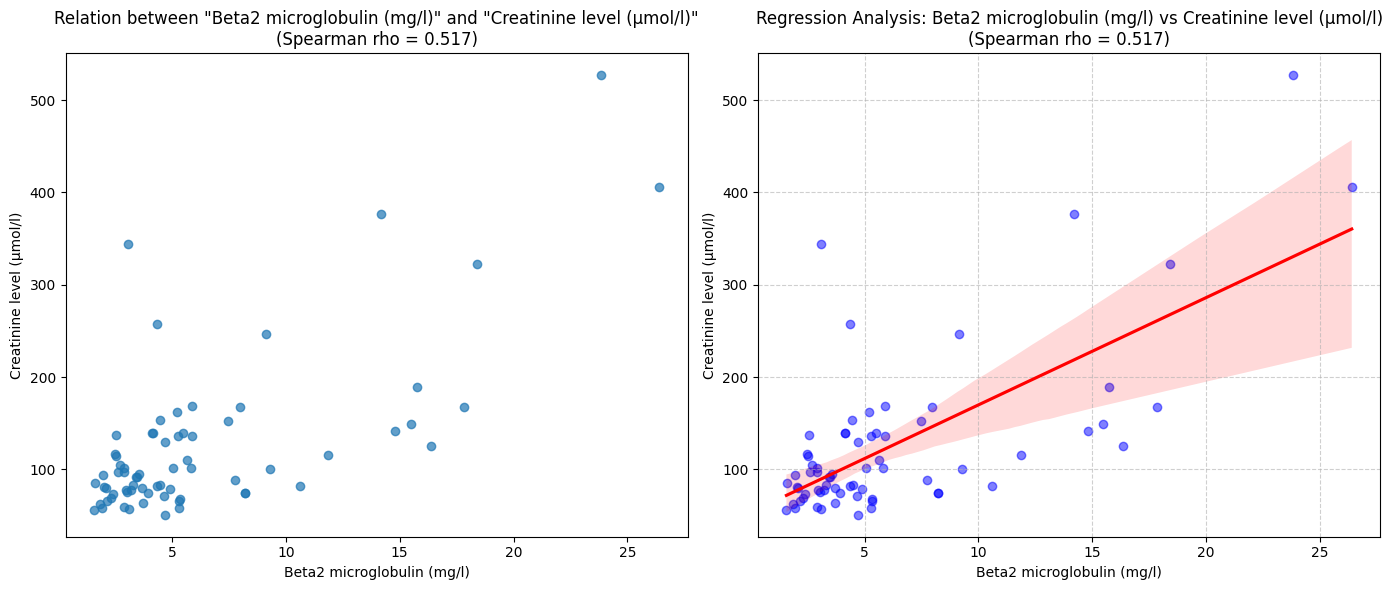

In [8]:
# 1. Load the clinical dataset with the appropriate encoding
df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# Define target features for analysis
f1 = 'Beta2 microglobulin (mg/l)'
f2 = 'Creatinine level (µmol/l)'

# STATISTICAL ANALYSIS: Spearman Rank Correlation
# Drop rows where either of the selected features has missing values (NaN)
cleaned_data = df[[f1, f2]].dropna()

# Compute Spearman correlation coefficient and p-value
correlation_coeff, p_value = spearmanr(cleaned_data[f1], cleaned_data[f2])

print(f"--- Spearman Correlation Analysis ---")
print(f"Features: '{f1}' vs '{f2}'")
print(f"Correlation Coefficient (rho): {correlation_coeff:.4f}")
print(f"p-value: {p_value:.5f}")
print(f"Statistically Significant: {p_value < 0.05}\n")

# VISUALIZATION: Side-by-Side Plots
# Initialize a single figure with 1 row and 2 columns
plt.figure(figsize=(14, 6))

# --- Scatter Plot ---
plt.subplot(1, 2, 1)
plt.scatter(cleaned_data[f1], cleaned_data[f2], alpha=0.7)
plt.xlabel(f1)
plt.ylabel(f2)
plt.title(f'Relation between "{f1}" and "{f2}"\n(Spearman rho = {correlation_coeff:.3f})', fontsize=12)

# --- Regression Plot ---
plt.subplot(1, 2, 2)
sns.regplot(
    data=cleaned_data,
    x=f1,
    y=f2,
    scatter_kws={'alpha': 0.5, 'color': 'blue'},
    line_kws={'color': 'red'}
)
plt.xlabel(f1)
plt.ylabel(f2)
plt.title(f'Regression Analysis: {f1} vs {f2}\n(Spearman rho = {correlation_coeff:.3f})', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Adjust spacing and display the final figure
plt.tight_layout()
plt.show()

# Boxplot and Kruskal-Wallis test

--- Kruskal-Wallis Test: Beta2 microglobulin (mg/l) across ISS classification ---
H-statistic: 58.7842
p-value: 0.00000
Statistically Significant: True


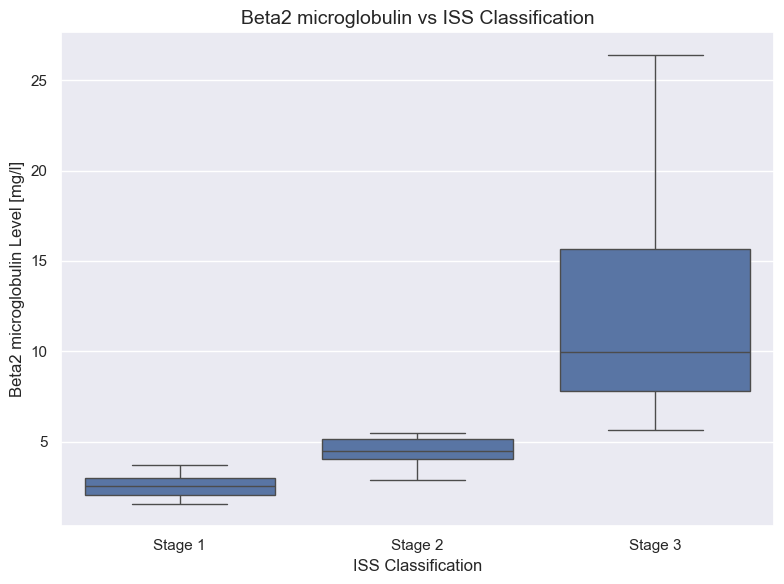

In [9]:
# 1. Load the clinical dataset with the appropriate encoding
df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# Define our target columns for easier handling
group_col = 'ISS classification'
value_col = 'Beta2 microglobulin (mg/l)'

# 2. STATISTICAL ANALYSIS: Kruskal-Wallis Test
# Group the target values based on the unique categories in ISS classification
# We drop missing values (NaNs) to ensure the test executes successfully
groups = [group[value_col].dropna() for name, group in df.groupby(group_col)]

print(f"--- Kruskal-Wallis Test: {value_col} across {group_col} ---")
if len(groups) > 1:
    h_stat, p_value = kruskal(*groups)
    print(f"H-statistic: {h_stat:.4f}")
    print(f"p-value: {p_value:.5f}")
    print(f"Statistically Significant: {p_value < 0.05}")
else:
    print("Skipped: Not enough unique groups to perform the test.")


# 3. VISUALIZATION: Boxplot
sns.set_theme(style="darkgrid")

# Initialize the figure size
plt.figure(figsize=(8, 6))

# Generate the boxplot visualization
sns.boxplot(x=group_col, y=value_col, data=df)

# Formatting labels and title
plt.xlabel('ISS Classification')
plt.ylabel('Beta2 microglobulin Level [mg/l]')
plt.title('Beta2 microglobulin vs ISS Classification', fontsize=14)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Clinical risk score

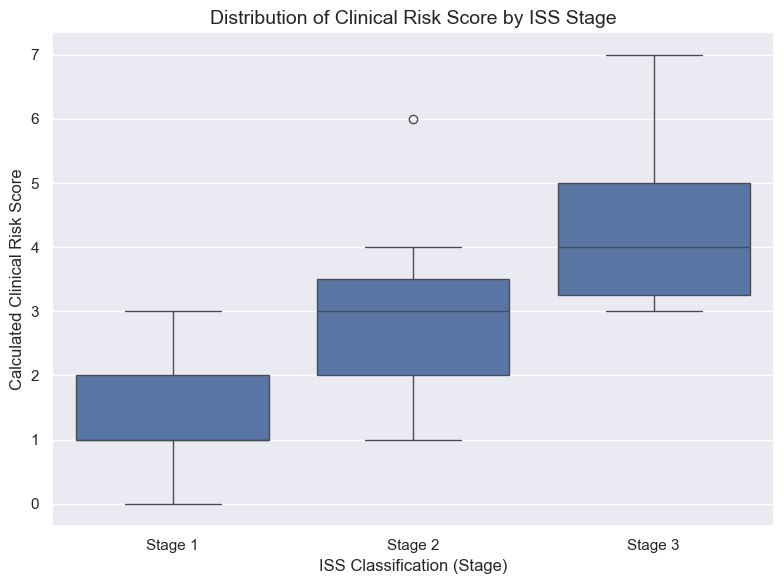

In [12]:
# 1. Load the clinical dataset with the appropriate encoding
df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# Clinical Risk Score Calculation
# Calculate Kappa/Lambda ratio
df['kappa lambda ratio'] = df['Serum kappa FLC quantity (mg/l'] / df['Serum lambda FLC quantity (mg/l)']

# --- Score 1: Tumor Burden ---
df["score_tumor_burden"] = 0
df.loc[df["Serum M-protein quantity (g/l)"] > 30, "score_tumor_burden"] += 1
df.loc[df["Plasmocyte count FC (%)"] > 30, "score_tumor_burden"] += 1
df.loc[df["kappa lambda ratio"] > 100, "score_tumor_burden"] += 1

# --- Score 2: Clone Type ---
df["score_clone"] = 0
df.loc[df["M-protein type"] == "IgA", "score_clone"] = 1
df.loc[df["M-protein type"] == "IgG", "score_clone"] = 1
df.loc[df["M-protein type"] == "Light-chain", "score_clone"] = 2

# --- Score 3: CRAB Criteria (Simplified) ---
df["score_crab"] = 0
df.loc[df["Calcium total level (mmol/l)"] > 2.75, "score_crab"] += 1
df.loc[df["Creatinine level (µmol/l)"] > 177, "score_crab"] += 1

# --- Score 4: Prognosis (Based on Beta2 Microglobulin) ---
df["score_prognosis"] = 0
df.loc[(df["Beta2 microglobulin (mg/l)"] >= 3.5) & (df["Beta2 microglobulin (mg/l)"] < 5.5), "score_prognosis"] = 1
df.loc[df["Beta2 microglobulin (mg/l)"] >= 5.5, "score_prognosis"] = 2

# --- Final Aggregation: Total Clinical Risk Score ---
df["clinical_risk_score"] = (
    df["score_tumor_burden"] +
    df["score_clone"] +
    df["score_crab"] +
    df["score_prognosis"]
)

# VISUALIZATION: Risk Score by Stage
# Set a consistent clean theme
sns.set_theme(style="darkgrid")

# Initialize figure size
plt.figure(figsize=(8, 6))

# Generate boxplot to see the distribution of custom risk score across ISS stages
sns.boxplot(data=df, x="ISS classification", y="clinical_risk_score")

# Format labels and title
plt.xlabel('ISS Classification (Stage)')
plt.ylabel('Calculated Clinical Risk Score')
plt.title('Distribution of Clinical Risk Score by ISS Stage', fontsize=14)

# Render the plot
plt.tight_layout()
plt.show()

# Chi-squared test

In [13]:
# 1. Global Pandas configuration to handle future deprecations cleanly
pd.set_option('future.no_silent_downcasting', True)

# 2. Load the clinical dataset with the appropriate encoding
df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

# 3. Map categorical ISS classification text to numeric Stage values
# (Maintains the structure of the input dataset safely)
df['Stage'] = df['ISS classification'].replace({
    'Stage 1': 1,
    'Stage 2': 2,
    'Stage 3': 3
})

# STATISTICAL ANALYSIS: Chi-Squared Test of Independence
# Generate a contingency table (cross-tabulation) between the two variables
contingency_table = pd.crosstab(df['M-protein type'], df['Stage'])
print("--- Contingency Table (Observed Counts) ---")
print(contingency_table)
print("-" * 43)

# Perform the Chi-Squared test
chi2_stat, p_value, dof, expected_frequencies = chi2_contingency(contingency_table)

# Display formatted test results
print("--- Chi-Squared Test Results ---")
print(f"Chi2 Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"p-value: {p_value:.5f}")
print(f"Statistically Significant (p < 0.05): {p_value < 0.05}")

--- Contingency Table (Observed Counts) ---
Stage            1   2   3
M-protein type            
IgA              1   4   5
IgG             16  18  13
LC only          7   1   4
-------------------------------------------
--- Chi-Squared Test Results ---
Chi2 Statistic: 7.7178
Degrees of Freedom: 4
p-value: 0.10248
Statistically Significant (p < 0.05): False
